In [1]:
# importing functions
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
#%matplotlib ipympl

In [2]:
# this will be plotted in the histograms
pin_gpr = np.genfromtxt(r'C:\Users\slaar\Desktop\project\pinnacle_RS_comparison\pinnacle_final_30_patients_structures_df.csv', dtype=None, delimiter = ',') # loading the table containing the gamma passng rates (%GP) for each structure from the Pinnacle scans (PIN)
#pin_gpr = DataFrame.from_csv(r'C:\Users\slaar\Desktop\project\pinnacle_RS_comparison\pinnacle_final_30_patients_structures_df.csv', sep = ',') # loading the table containing the gamma passng rates (%GP) for each structure from the Pinnacle scans (PIN)

#pin_gpr_header = np.genfromtxt(r'C:\Users\slaar\Desktop\project\pinnacle_RS_comparison\pinnacle_final_30_patients_structures_df.csv', skip_header = 1, dtype = str, delimiter = ',') # loading the table containing the gamma passng rates (%GP) for each structure from the Pinnacle scans (PIN)
rs_gpr = np.genfromtxt(r'C:\Users\slaar\Desktop\project\pinnacle_RS_comparison\RS_final_32_patients_structure_df.txt', delimiter = "\t", dtype = None) # loading the table containing the %GP for each structure from the RayStation (rs) scans

# this will be plotted as dotted vertical lines in the histograms
pin_tl_al = np.genfromtxt(r'C:\Users\slaar\Desktop\project\pinnacle_RS_comparison\pinnacle_final_30_patients_results_df.csv', delimiter = ',', dtype = None, skip_header = 1) # loadin the table of AL and TL - the structures of files is first row
rs_tl_al = np.genfromtxt(r'C:\Users\slaar\Desktop\project\pinnacle_RS_comparison\RS_final_32_patients_results_df.txt',  delimiter = "\t", dtype = None, skip_header = 1)

In [3]:
print(pin_tl_al)

[('Bladder (3%/2mm).', 97.35808, 89.71101)
 ('Bladder (3%/3mm).', 99.23205, 97.02426)
 ('Left Femoral Head (3%/2mm).', 86.62535, 57.94091)
 ('Left Femoral Head (3%/3mm).', 94.9954 , 81.61772)
 ('Merlin Structure: PTVp DoseCheck20 (3%/3mm).', 99.72216, 98.77763)
 ('Merlin Structure: PTVp DoseCheck20(3%/2mm).', 99.56294, 98.19195)
 ('Merlin Structure: PTVp HighDose (3%/3mm).', 99.88262, 99.51785)
 ('Merlin Structure: PTVp HighDose(3%/2mm).', 99.80134, 99.2096 )
 ('Merlin Structure: PTVp+OAR DoseCheck20 (3%/3mm).', 98.70045, 95.54053)
 ('Merlin Structure: PTVp+OAR DoseCheck20(3%/2mm).', 96.46834, 88.64016)
 ('PTVp 48 (3%/2mm).', 99.56294, 98.19195)
 ('PTVp 48 (3%/3mm).', 99.72216, 98.77763)
 ('PTVp 57.6 (3%/2mm).', 99.82477, 99.32163)
 ('PTVp 57.6 (3%/3mm).', 99.90455, 99.62058)
 ('PTVp 60 (3%/2mm).', 99.80134, 99.2096 )
 ('PTVp 60 (3%/3mm).', 99.88262, 99.51785)
 ('Rectum (3%/2mm).', 98.36176, 94.10932)
 ('Rectum (3%/3mm).', 99.26273, 97.38172)
 ('Right Femoral Head (3%/2mm).', 81.54242,

In [4]:
pin_dict = {}
for index in range(0,len(pin_gpr[0])):
    list_pin_gprs = []
    for i in range(1,(len(pin_gpr))):
        list_pin_gprs.append(float(pin_gpr[i][index]))
    list_pin_tl = float(pin_tl_al[index][1])
    list_pin_al = float(pin_tl_al[index][2])

    pin_dict[pin_gpr[0][index]] = [list_pin_gprs, list_pin_tl, list_pin_al]


rs_dict = {}
for index in range(0,len(rs_gpr[0])):
    list_rs_gprs = []
    for i in range(1,(len(rs_gpr))):
        list_rs_gprs.append(float(rs_gpr[i][index]))
    list_rs_tl = float(rs_tl_al[index][1])
    list_rs_al = float(rs_tl_al[index][2])

    rs_dict[rs_gpr[0][index]] = [list_rs_gprs, list_rs_tl, list_rs_al]

print(rs_dict) # has a dictionary with the string of the structure name being thhe key and the values are a list of three items the first item being aa list of %gp, second iten being the tl and the third being the al
# means and std can be done after the values 

{np.str_('Bladder (3%/2mm).'): [[95.5, 97.88, 92.16, 95.32, 87.91, 98.85, 86.18, 98.0, 95.13, 88.68, 86.61, 92.49, 98.22, 95.79, 84.87, 96.35, 97.79, 98.52, 90.59, 98.72, 99.05, 93.75, 99.42, 99.09, 94.3, 95.72, 94.26, 99.56, 95.61, 98.76, 74.07, 97.39, 98.56], 92.27811, 76.31683], np.str_('Bladder (3%/3mm).'): [[98.53, 99.21, 96.31, 99.14, 95.49, 99.82, 96.23, 99.56, 98.73, 94.85, 93.4, 98.34, 99.75, 98.86, 91.43, 99.34, 99.38, 99.81, 96.01, 99.97, 99.41, 98.84, 99.63, 99.89, 98.2, 98.1, 98.2, 99.96, 98.29, 99.84, 85.74, 99.21, 99.55], 96.66622, 88.97237], np.str_('IDC ROI (3%/3mm).'): [[95.05, 94.32, 92.73, 97.05, 94.21, 98.08, 94.3, 94.85, 94.72, 92.18, 88.79, 88.62, 96.81, 93.64, 82.12, 97.55, 98.07, 88.69, 76.9, 98.61, 95.42, 95.65, 90.26, 98.74, 97.1, 95.41, 96.36, 92.58, 93.3, 93.46, 83.49, 92.52, 89.98], 91.26213, 74.53831], np.str_('IDC ROI(3%/2mm).'): [[92.78, 92.02, 89.21, 94.32, 89.62, 96.89, 88.35, 91.82, 91.39, 88.12, 82.06, 82.97, 94.63, 90.76, 74.13, 94.84, 96.5, 84.03,

In [5]:
rs_names = []
for j in range(0,len(rs_gpr[0])):
    name = rs_gpr[0][j]
    rs_names.append(name)

pin_names = []
for j in range(0, len(pin_gpr[0])):
    name = pin_gpr[0][j]
    pin_names.append(name)

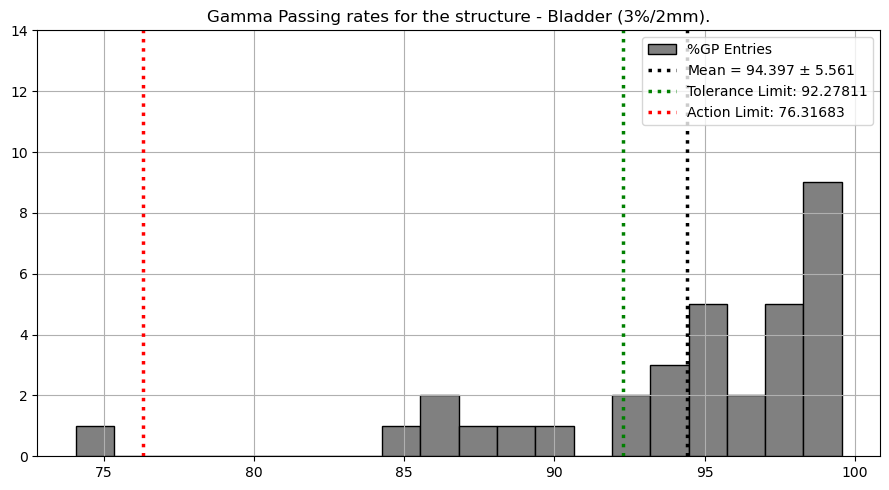

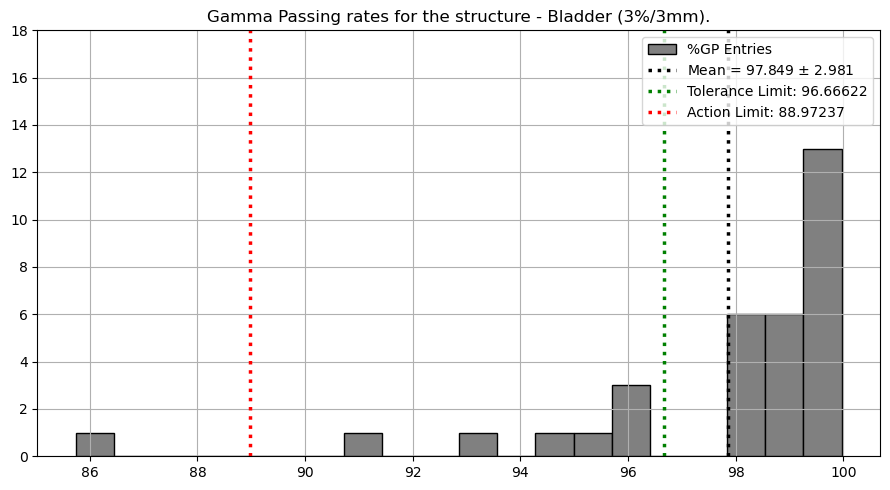

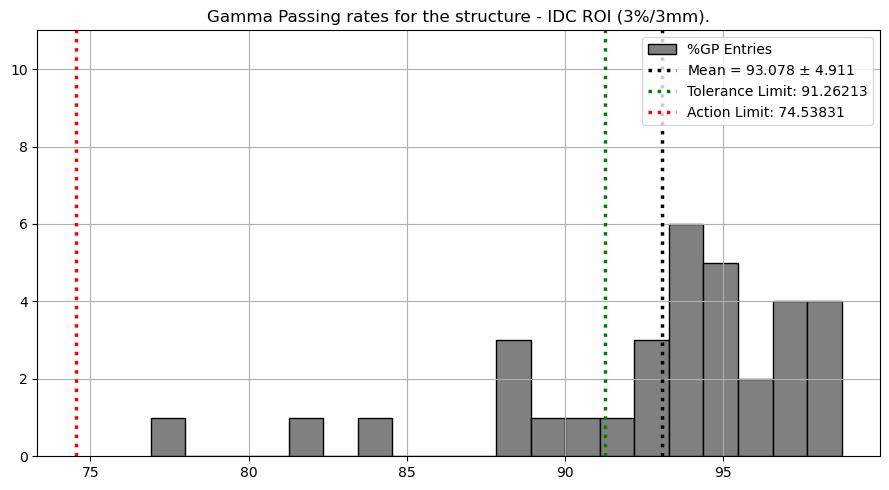

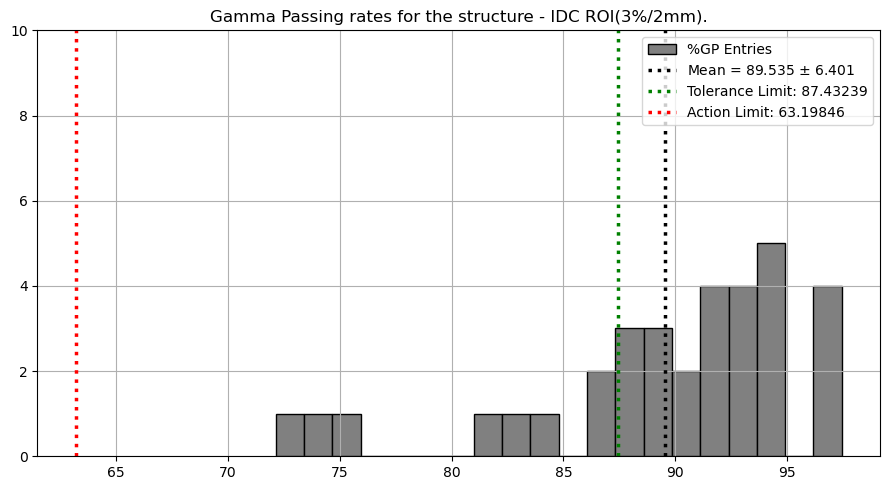

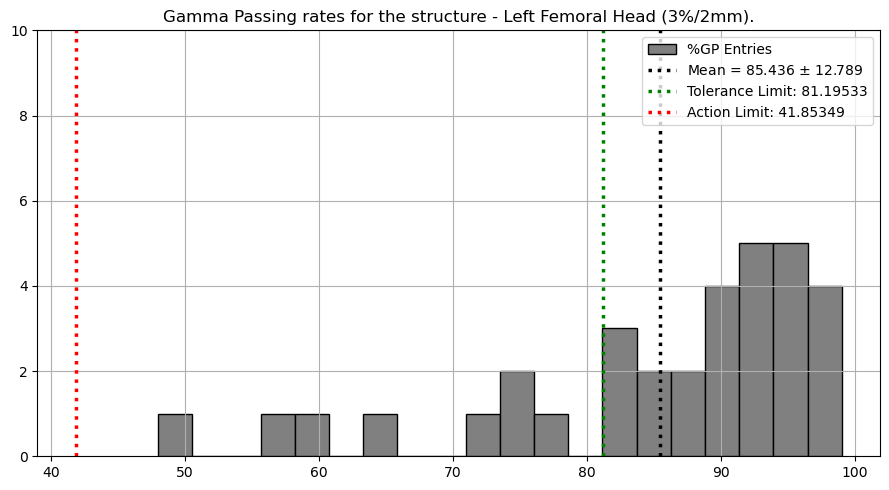

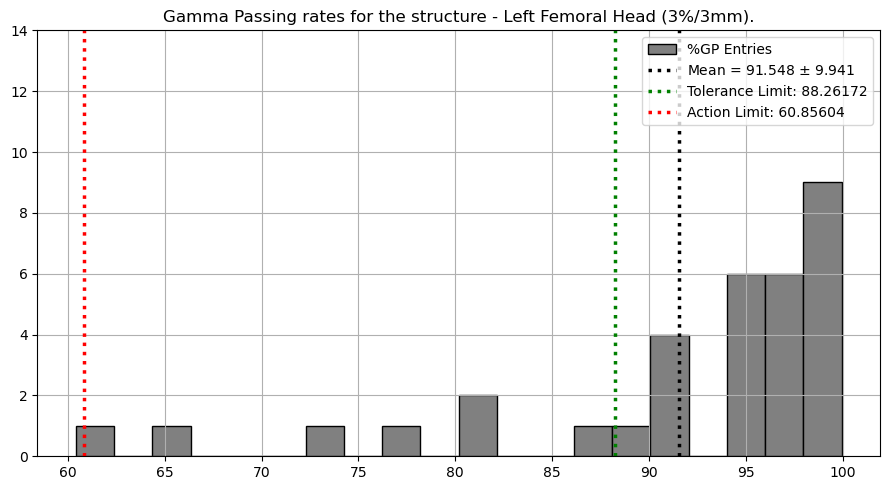

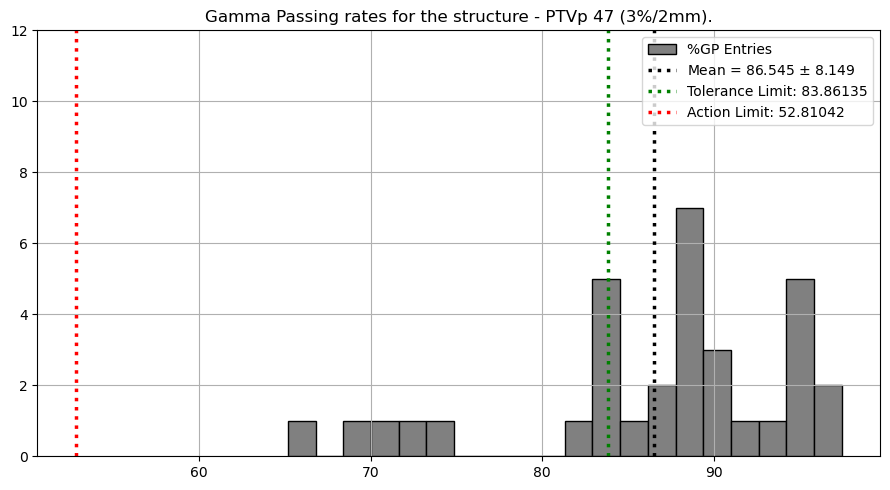

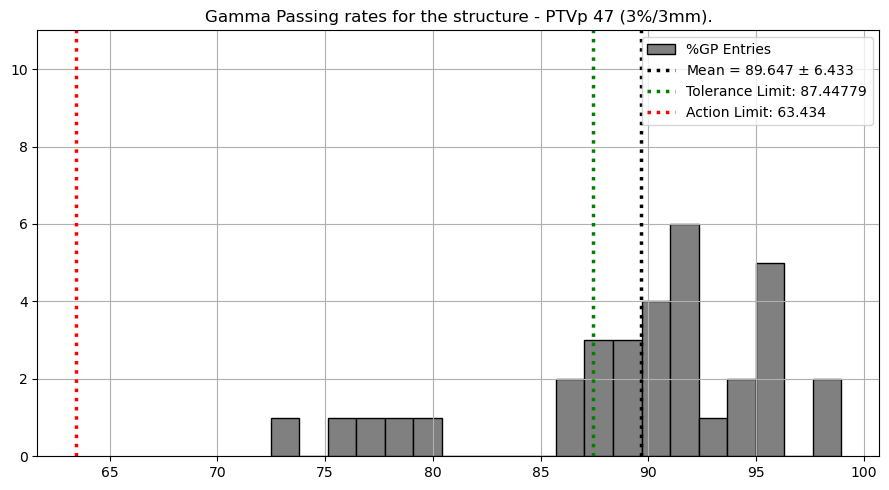

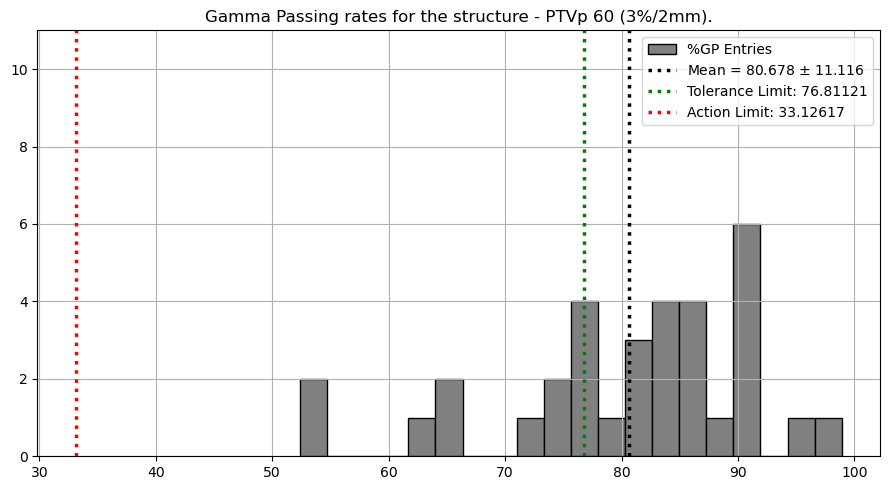

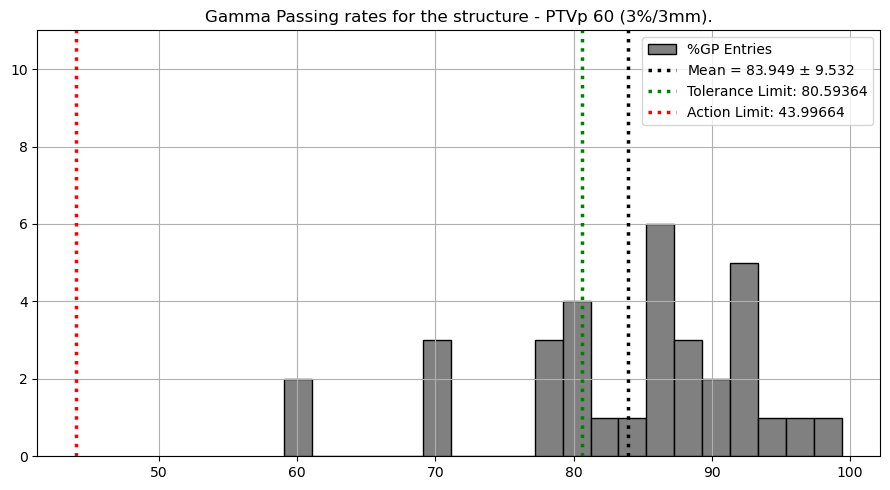

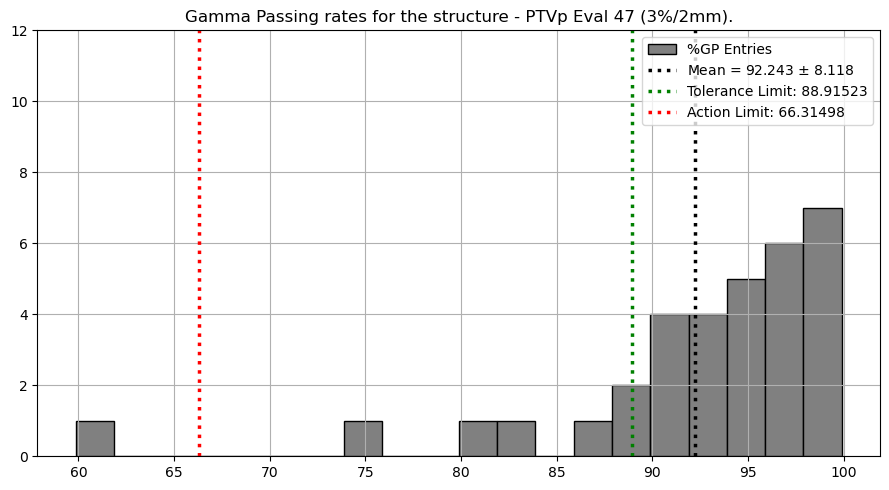

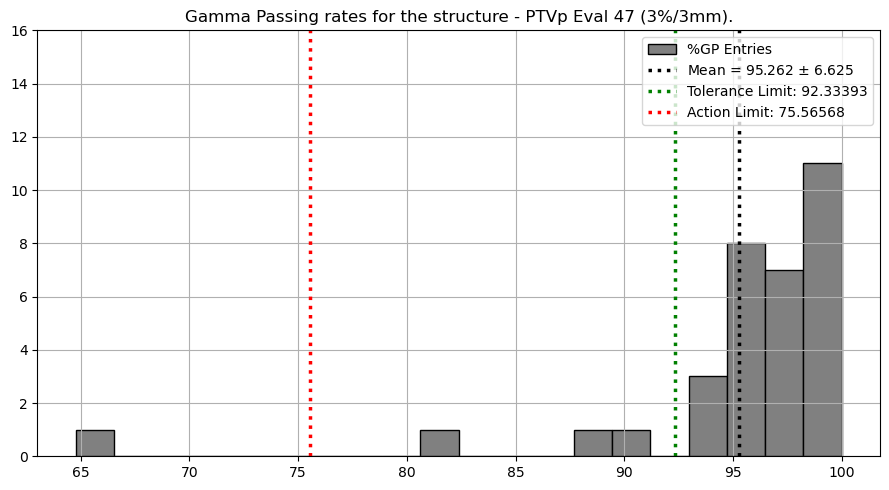

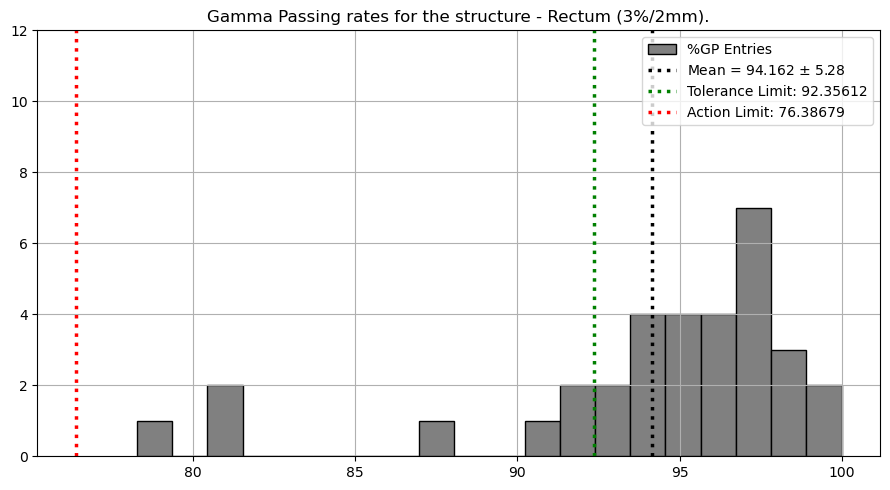

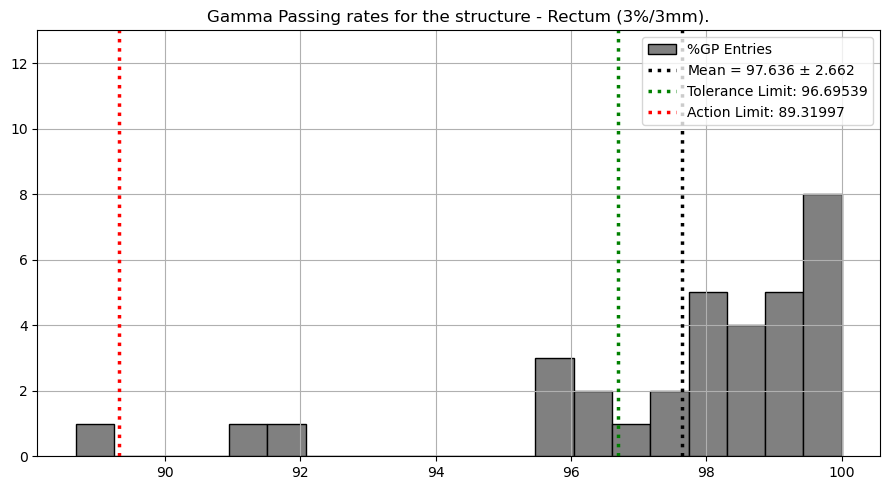

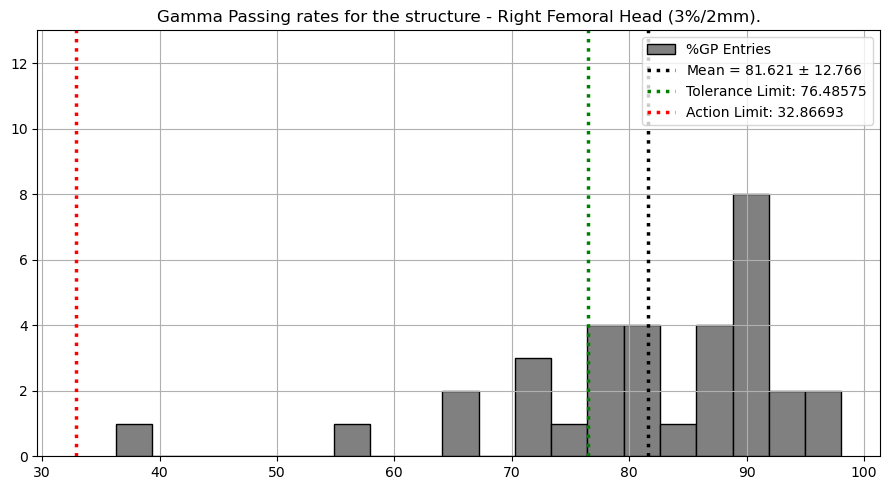

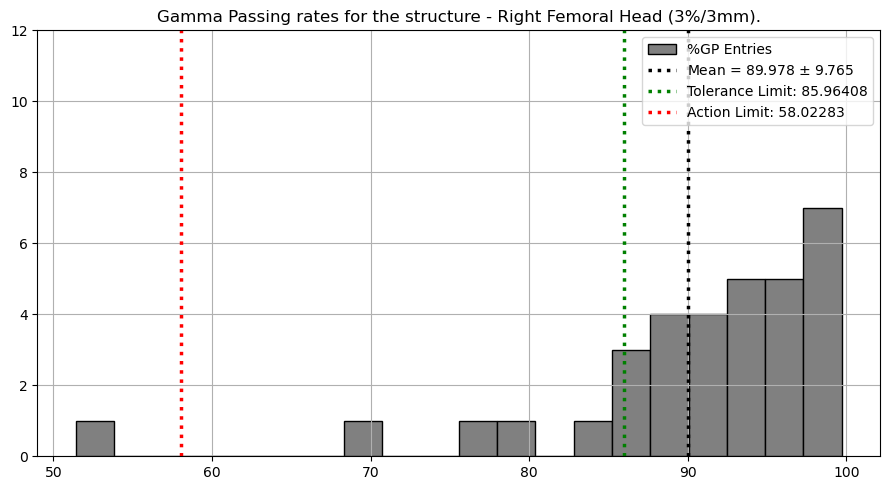

In [10]:
for i in rs_names:
    savefile1 = i.replace('.', '')
    savefile2 = savefile1.replace(' ', '')
    savefile3 = savefile2.replace('(', '')
    savefile4 = savefile3.replace(')', '')
    savefile5 = savefile4.replace(r'/', '')
    savefile6 = savefile5.replace('%', '')
    savefile = savefile6 + 'rs'
    mean_rs = np.mean(rs_dict[i][0])
    std_rs = np.std(rs_dict[i][0], ddof = 1)
    plt.figure(figsize = (9,5))
    plt.title(f'Gamma Passing rates for the structure - {i}')
    y,x,_ = plt.hist(rs_dict[i][0], color = 'grey', label = r'%GP Entries', bins = 20, edgecolor = 'black')
    plt.ylim(0, y.max()+5)
    plt.vlines(mean_rs, color = 'black', label = f'Mean = {np.round(mean_rs, 3)} $\pm$ {np.round(std_rs,3)}', ymin = 0, ymax = y.max()+5, linewidth = 2.5, linestyle = 'dotted')
    plt.vlines(rs_dict[i][1], color = 'green', label = f'Tolerance Limit: {rs_dict[i][1]}', ymin = 0, ymax = y.max()+5, linewidth = 2.5, linestyle = 'dotted')
    plt.vlines(rs_dict[i][2], color = 'red', label = f'Action Limit: {rs_dict[i][2]}', ymin = 0, ymax = y.max()+5, linewidth = 2.5, linestyle = 'dotted')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'C:\\Users\\slaar\\Desktop\\project\\pinnacle_RS_comparison\\plots\\{savefile}.png')
    plt.show()

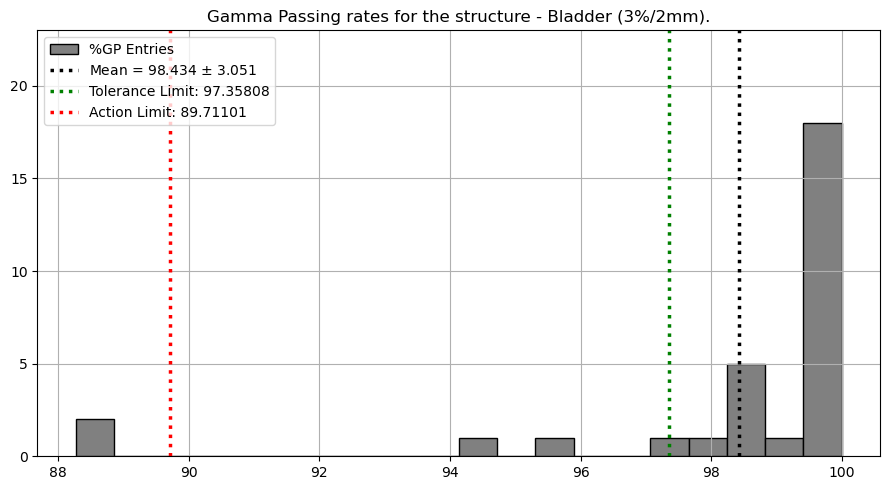

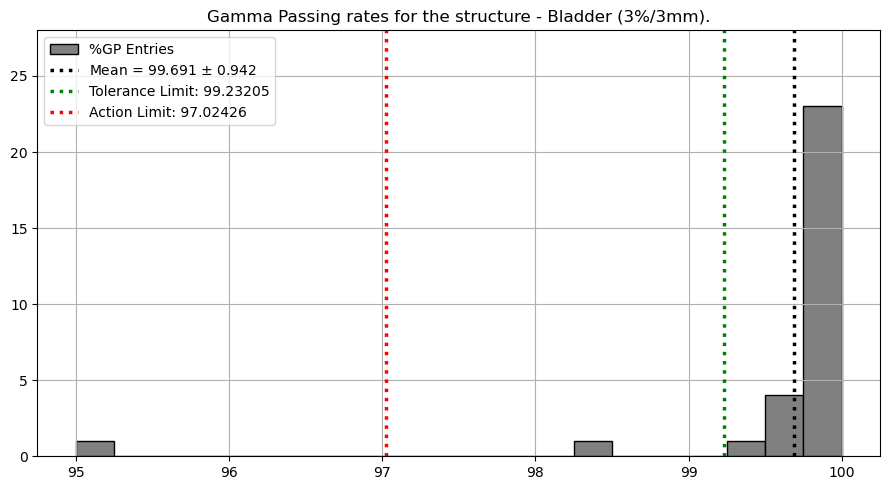

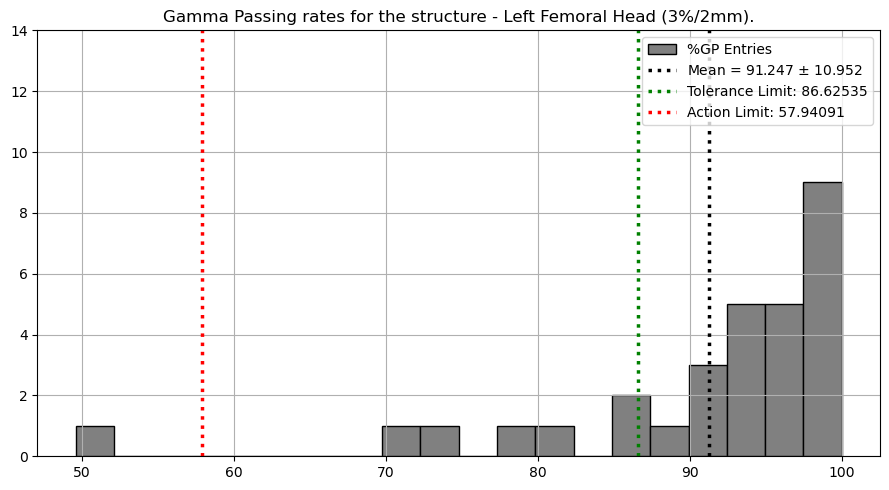

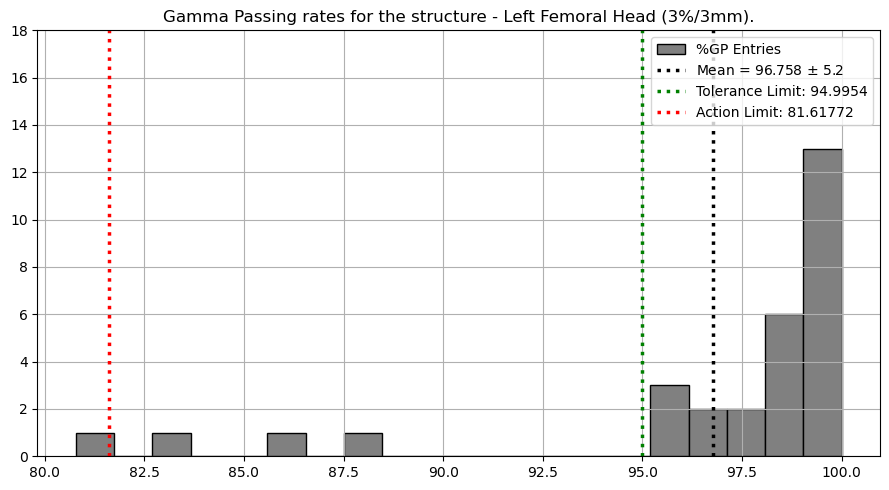

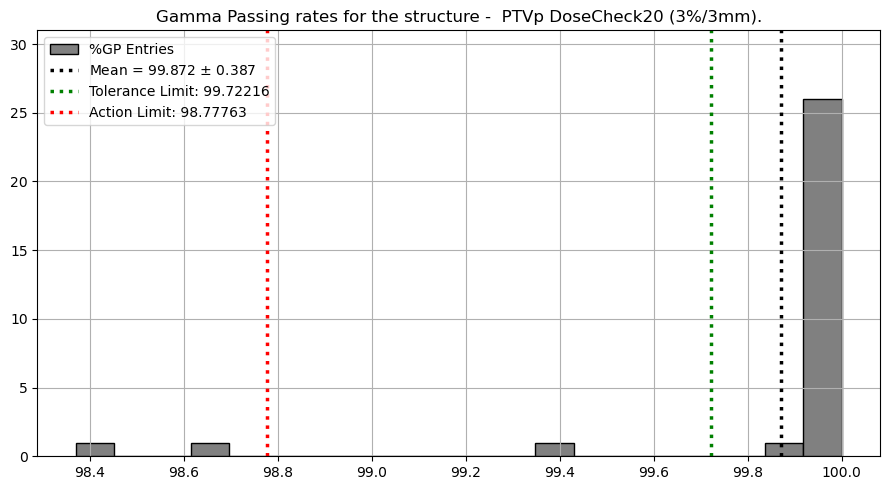

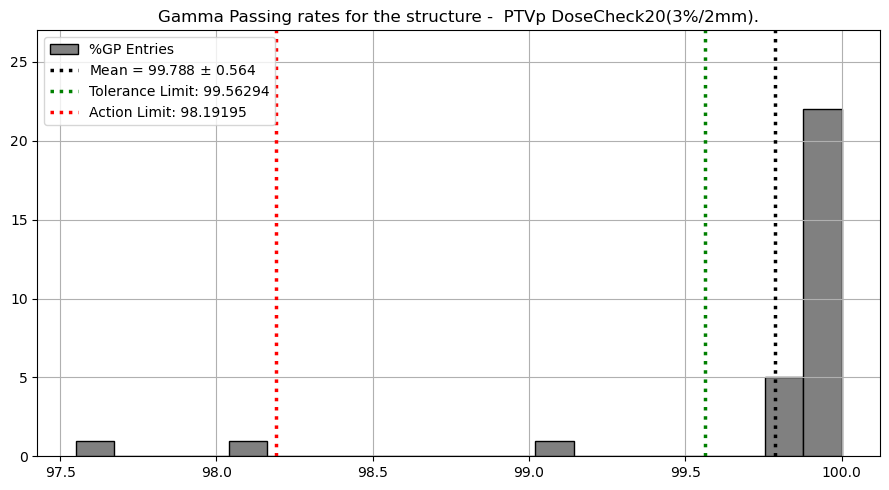

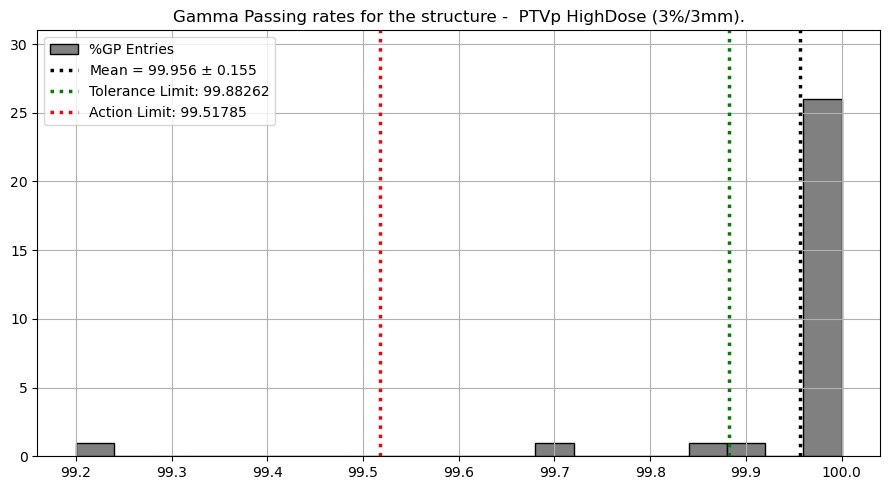

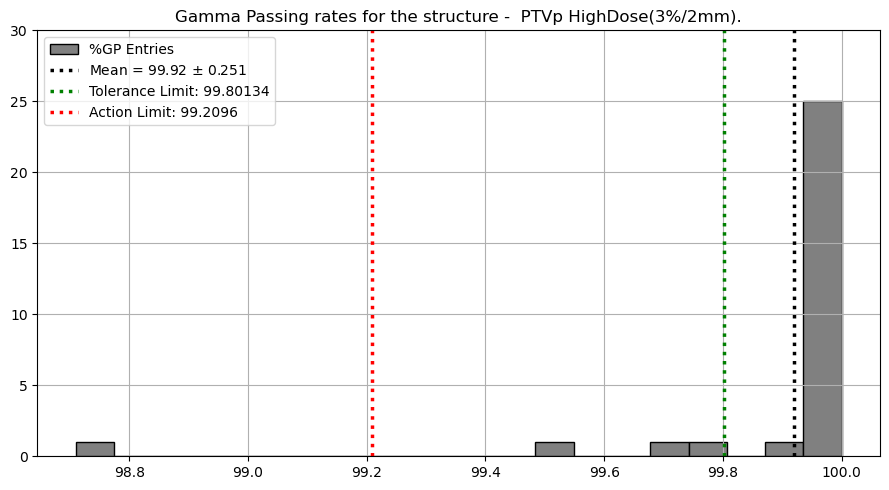

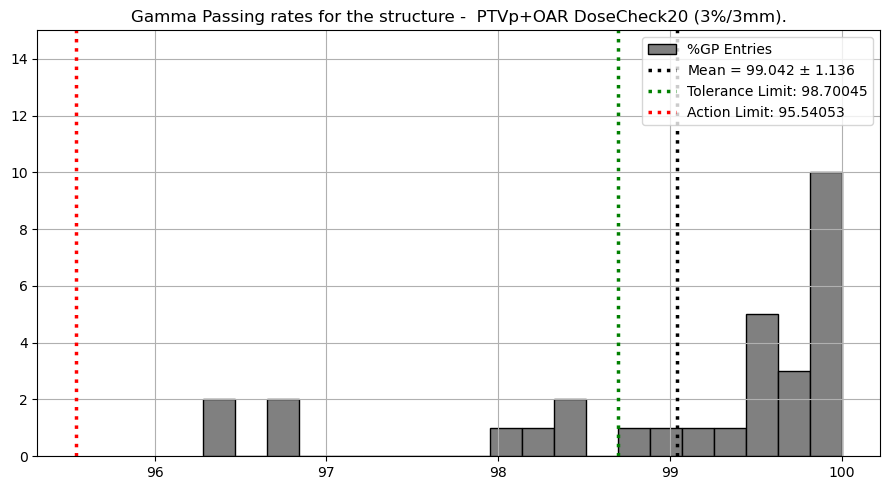

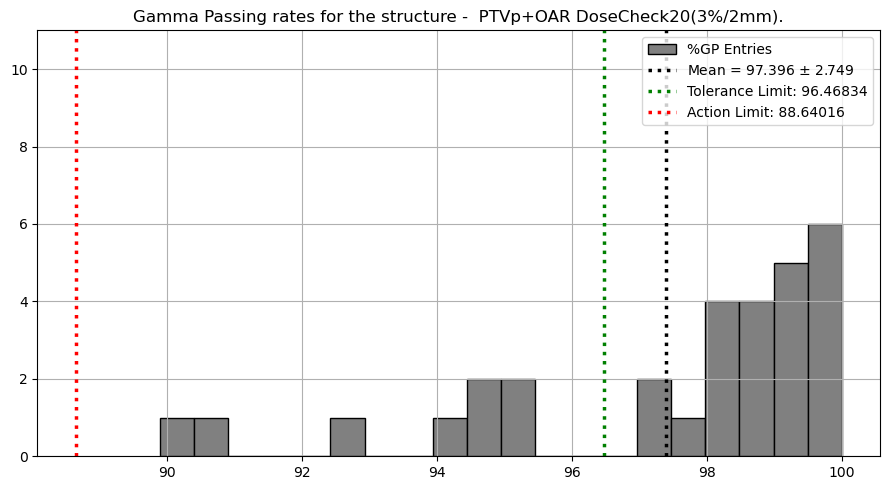

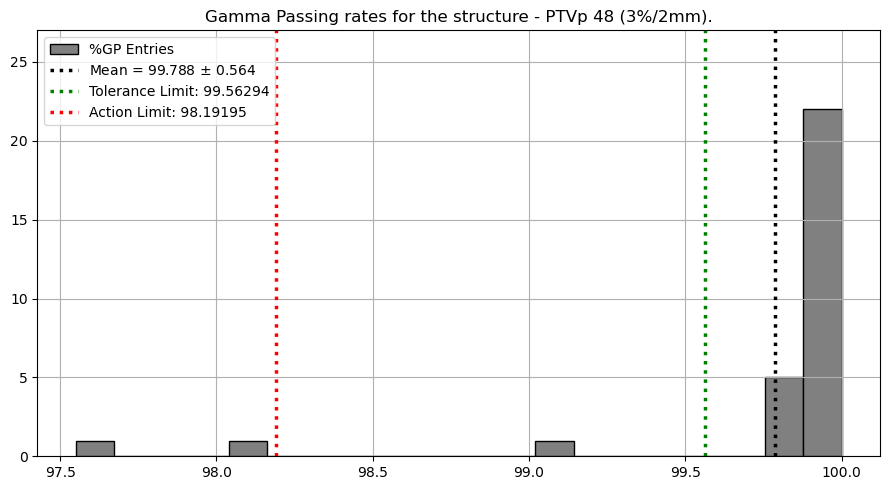

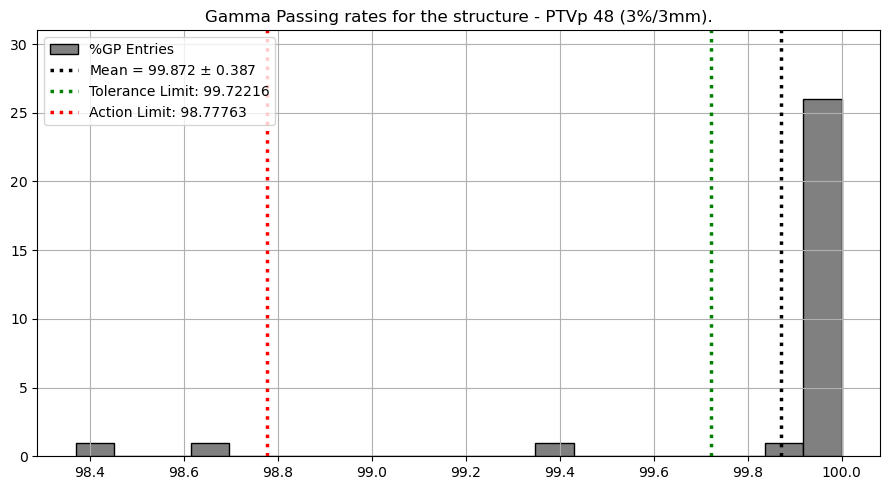

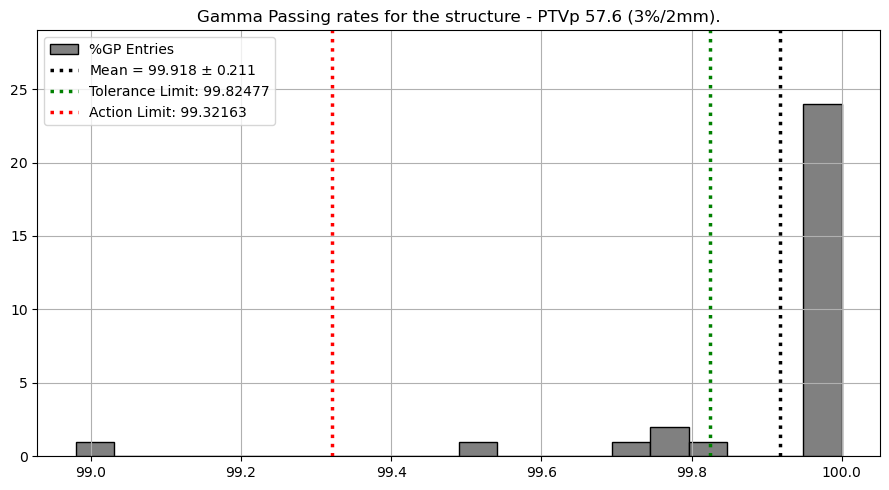

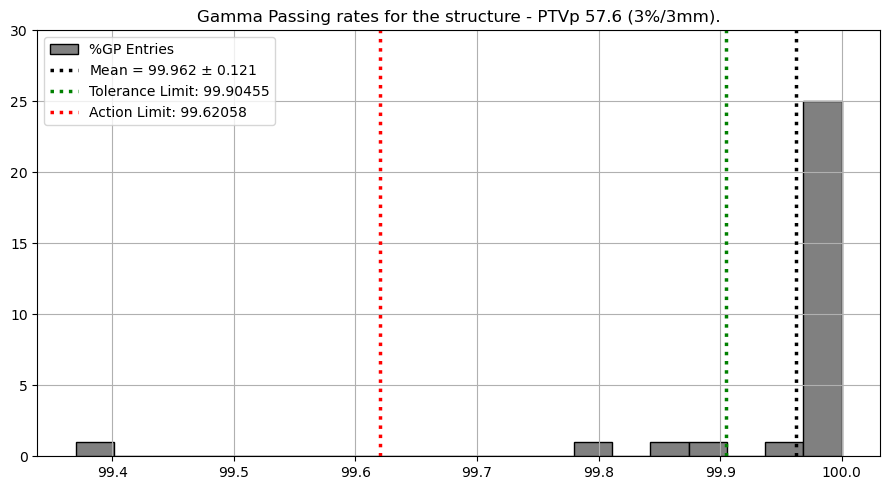

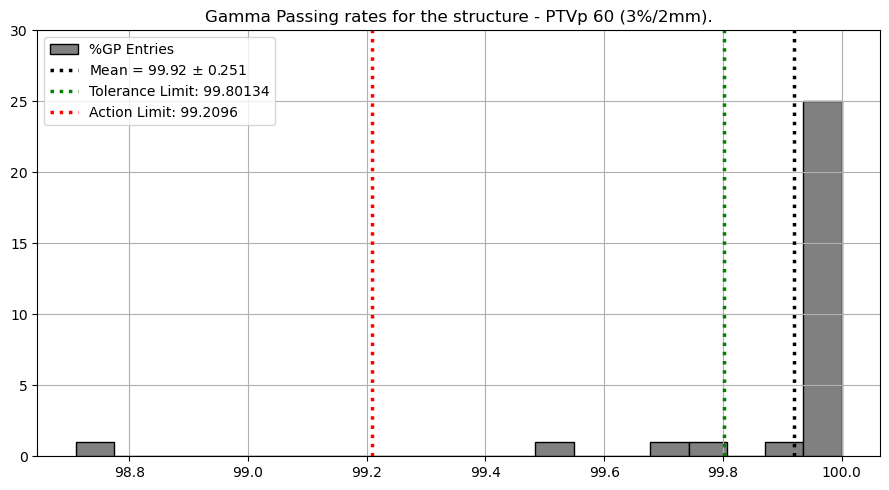

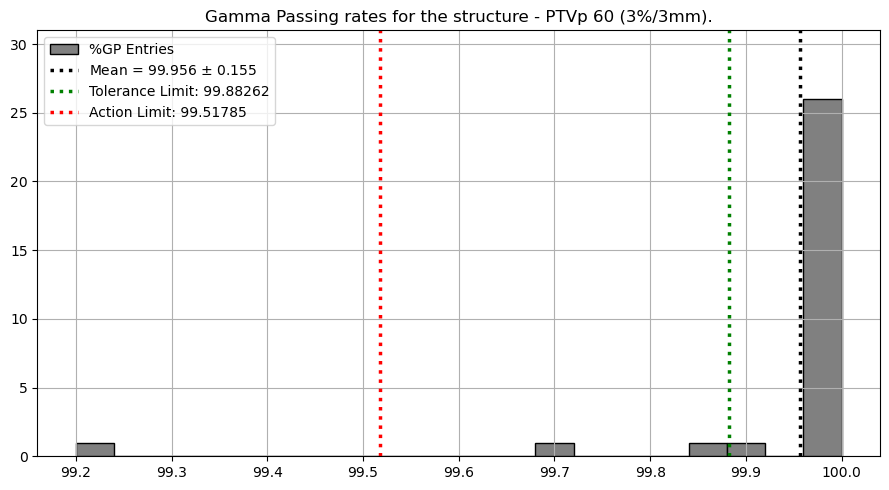

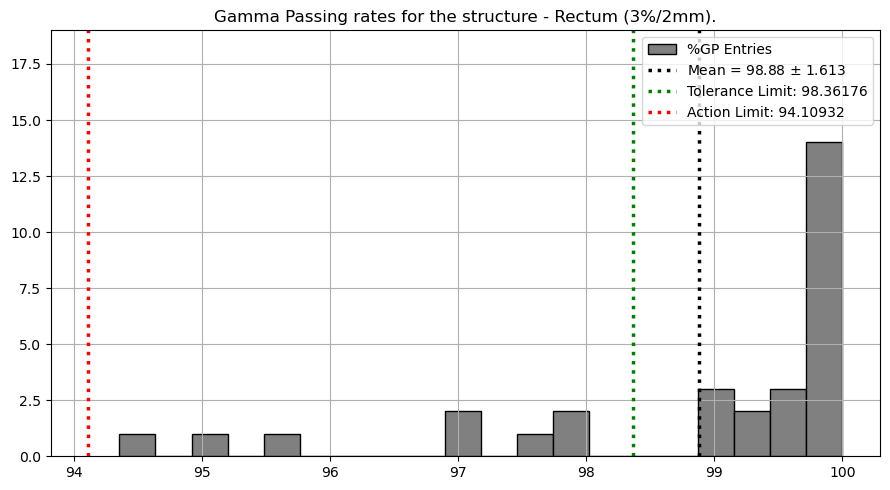

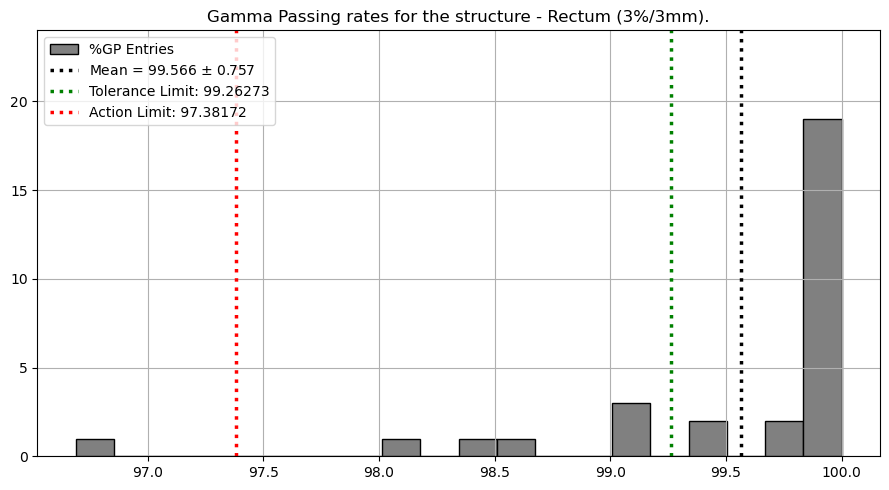

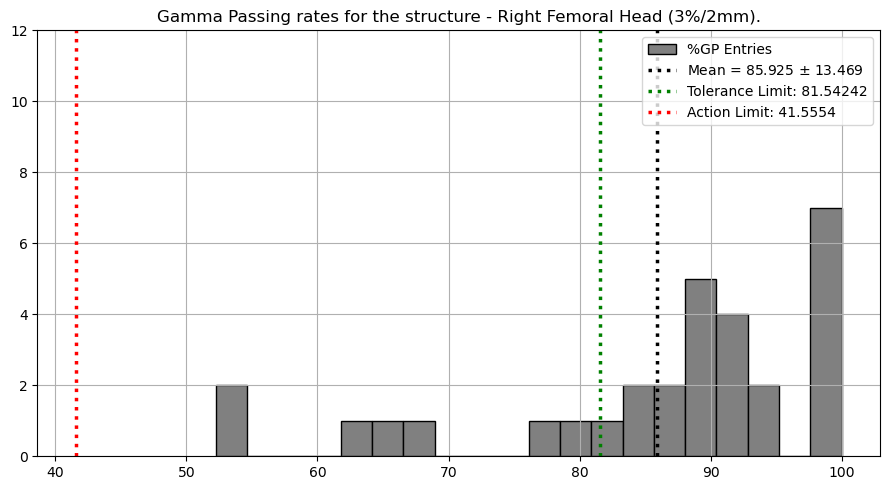

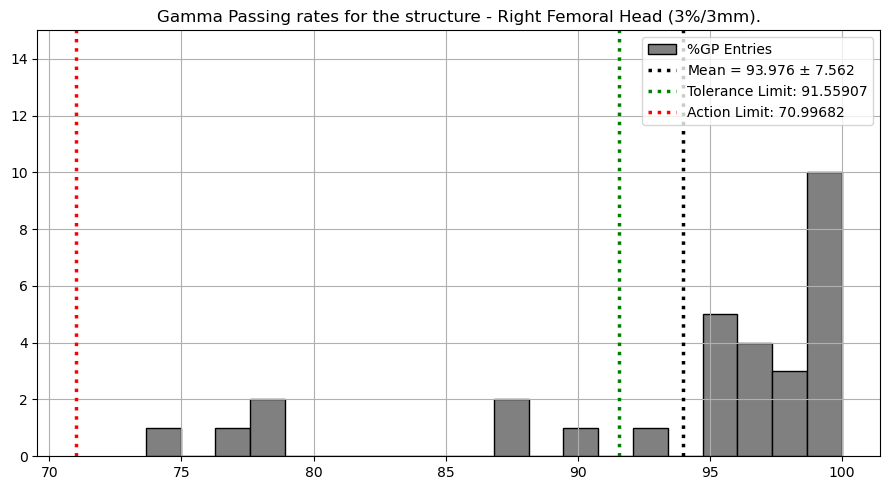

In [11]:
plt.close()
for i in pin_names:
    if i == 'Merlin Structure: PTVp+OAR DoseCheck20(3%/2mm).' or 'Merlin Structure: PTVp+OAR DoseCheck20(3%/3mm).':
        savefile1 = i.replace('.', '')
        savefile2 = savefile1.replace(' ', '')
        savefile3 = savefile2.replace('(', '')
        savefile4 = savefile3.replace(')', '')
        savefile5 = savefile4.replace(r'/', '')
        savefile55 = savefile5.replace('Merlin Structure:', '')
        savefile555 = savefile55.replace('%', '')
        savefile6= savefile555.replace('+', '')
        savefile = savefile6 + 'pin'
        mean_pin = np.mean(pin_dict[i][0])
        std_pin = np.std(pin_dict[i][0], ddof = 1)
        plt.figure(figsize = (9,5))
        plt.title(f'Gamma Passing rates for the structure - {i.replace('Merlin Structure:', '')}')
        y,x,_ = plt.hist(pin_dict[i][0], color = 'grey', label = r'%GP Entries', bins = 20, edgecolor = 'black')
        plt.ylim(0, y.max()+5)
        plt.vlines(mean_pin, color = 'black', label = f'Mean = {np.round(mean_pin, 3)} $\pm$ {np.round(std_pin,3)}', ymin = 0, ymax = y.max()+5, linewidth = 2.5, linestyle = 'dotted')
        plt.vlines(pin_dict[i][1], color = 'green', label = f'Tolerance Limit: {pin_dict[i][1]}', ymin = 0, ymax = y.max()+5, linewidth = 2.5, linestyle = 'dotted')
        plt.vlines(pin_dict[i][2], color = 'red', label = f'Action Limit: {pin_dict[i][2]}', ymin = 0, ymax = y.max()+5, linewidth = 2.5, linestyle = 'dotted')
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'C:\\Users\\slaar\\Desktop\\project\\pinnacle_RS_comparison\\plots\\{savefile}.png')
        plt.show()